In [1]:
import sys
sys.path.append('../')
sys.path.append('../..')
import importlib
import hmm_fit # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_fit)
from hmm_functions import load_data
import hmm_group_analysis # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_group_analysis)
from hmm_group_analysis import create_hypothesis_testing_dataframe, separate_trans_probs
import _stats # import entire module so we can call importlib.reload() on it
importlib.reload(_stats)
from _stats import permtest_ind, permtest_rel

import numpy as np
import nibabel as nib
import pandas as pd
pd.set_option('display.max_colwidth', None)

import os
import pickle

from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
experiment = 'RLstim'
data_prep_method = 'LEiDA' # 'ICA' or 'LEiDA'

if experiment == 'LLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv') 
elif experiment == 'RLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/RLstim/right_fl_stim_phase_coherence_matrices_no_wm_116roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/RLstim/RLstim_info/metadata_corrected_rmCIMT49d006_cci007_not_combined.csv')

In [3]:
# Create data array X
X, full_data = load_data(
    data_path=data_path, 
    data_prep_method=data_prep_method, 
    standardize=False, # False for LEiDA
)

# Create subj_order and y
if data_prep_method == 'ICA':   
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            y.append(subj_order[i][:-4])
            i += 1

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    subj_order = metadata_corrected['subject_id'].unique()
    y = [subj[:-4] for subj in subj_order]
else:
    raise ValueError("invalid data_prep_method. Only ICA and LEiDA are supported")

subj_order = np.array(subj_order) # the subject labels in the EXACT order that the subjects appear in X
y = np.array(y) # the experimental cohort of each subject in the EXACT order that the subjects appear in X
print("X shape:", X.shape)
print("full_data attributes:", full_data)
print("subj_order shape:", subj_order.shape)
print("y shape:", y.shape)

Loading files:   0%|          | 0/113 [00:00<?, ?it/s]

X shape: (113, 250, 116)
full_data attributes: Data
 id: 13381405008
 n_sessions: 113
 n_samples: 28250
 n_channels: 116
subj_order shape: (113,)
y shape: (113,)


In [4]:
print(subj_order)

cohorts, cnt = np.unique_counts(y)
for i in range(len(cohorts)):
    print(f"Number of subjects in {cohorts[i]}: {cnt[i]}")

['CCI_CIMT_07d_001' 'CCI_CIMT_07d_004' 'CCI_CIMT_07d_006'
 'CCI_CIMT_07d_007' 'CCI_CIMT_07d_010' 'CCI_CIMT_07d_011'
 'CCI_CIMT_07d_020' 'CCI_CIMT_07d_022' 'CCI_CIMT_07d_024'
 'CCI_CIMT_07d_032' 'CCI_CIMT_07d_033' 'CCI_CIMT_07d_037'
 'CCI_CIMT_07d_038' 'CCI_CIMT_07d_039' 'CCI_CIMT_07d_040'
 'CCI_CIMT_21d_001' 'CCI_CIMT_21d_004' 'CCI_CIMT_21d_006'
 'CCI_CIMT_21d_007' 'CCI_CIMT_21d_010' 'CCI_CIMT_21d_011'
 'CCI_CIMT_21d_020' 'CCI_CIMT_21d_022' 'CCI_CIMT_21d_024'
 'CCI_CIMT_21d_032' 'CCI_CIMT_21d_033' 'CCI_CIMT_21d_037'
 'CCI_CIMT_21d_038' 'CCI_CIMT_21d_039' 'CCI_CIMT_21d_040'
 'CCI_CIMT_49d_001' 'CCI_CIMT_49d_004' 'CCI_CIMT_49d_007'
 'CCI_CIMT_49d_010' 'CCI_CIMT_49d_011' 'CCI_CIMT_49d_020'
 'CCI_CIMT_49d_022' 'CCI_CIMT_49d_024' 'CCI_CIMT_49d_032'
 'CCI_CIMT_49d_033' 'CCI_CIMT_49d_037' 'CCI_CIMT_49d_038'
 'CCI_CIMT_49d_039' 'CCI_CIMT_49d_040' 'CCI_none_07d_002'
 'CCI_none_07d_003' 'CCI_none_07d_005' 'CCI_none_07d_009'
 'CCI_none_07d_012' 'CCI_none_07d_013' 'CCI_none_07d_019'
 'CCI_none_07d

In [7]:
if data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

hmm_run

'LEiDA_116c_no_TDE'

In [8]:
results_path = f'{experiment}/results/{hmm_run}'
model_eval_log = {}
model_eval_log_save_path = results_path + f'/model_eval_log_{hmm_run}.pkl'

if os.path.exists(model_eval_log_save_path):
    with open(model_eval_log_save_path, 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs(results_path, exist_ok=True)

sorted(model_eval_log.keys())

[7]

# Compute Summary Statistics

## Load model of interest and compute preliminary summary statistics

In [9]:
k_optimal = 7
best_realization_idx = model_eval_log[k_optimal]['best_realization_idx']
model = load(model_eval_log[k_optimal]['best_realization_path'])

2026-05-29 15:43:27 INFO osl-dynamics [mod_base.py:781:load]: Loading model: RLstim/results/LEiDA_116c_no_TDE/7_states/7_states_model


In [10]:
inf_params_path = f'{results_path}/{k_optimal}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [11]:
alpha_path = f'{inf_params_path}/alp_{k_optimal}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

In [12]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 113)

In [13]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = np.array(modes.argmax_time_courses(alpha)) # state time course
print(stc.shape)

(113, 250, 7)


In [17]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(113, 7)

## Within-group FO

In [18]:
groups = {}

for group in np.unique(y):
    groups[group] = {}

In [19]:
def within_group_plotting_helper(metric, y_label):
    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
    plotting.plot_violin(
        np.concatenate((groups['CCI_CIMT_07d'][metric], groups['CCI_none_07d'][metric]), axis=0).T, 
        x_label="State", 
        y_label=y_label, 
        title="injured_07d", 
        ax=ax[0]
    )
    plotting.plot_violin(groups['SHM_none_07d'][metric].T, x_label="State", y_label=y_label, title="SHM_none_07d", ax=ax[1])
    
    for PID in ['07d', '21d', '49d']:
        fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
        plotting.plot_violin(groups['CCI_CIMT_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_CIMT_" + PID, ax=ax[0])
        plotting.plot_violin(groups['CCI_none_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_none_" + PID, ax=ax[1])
        plotting.plot_violin(groups['SHM_none_' + PID][metric].T, x_label="State", y_label=y_label, title="SHM_none_" + PID, ax=ax[2])

True


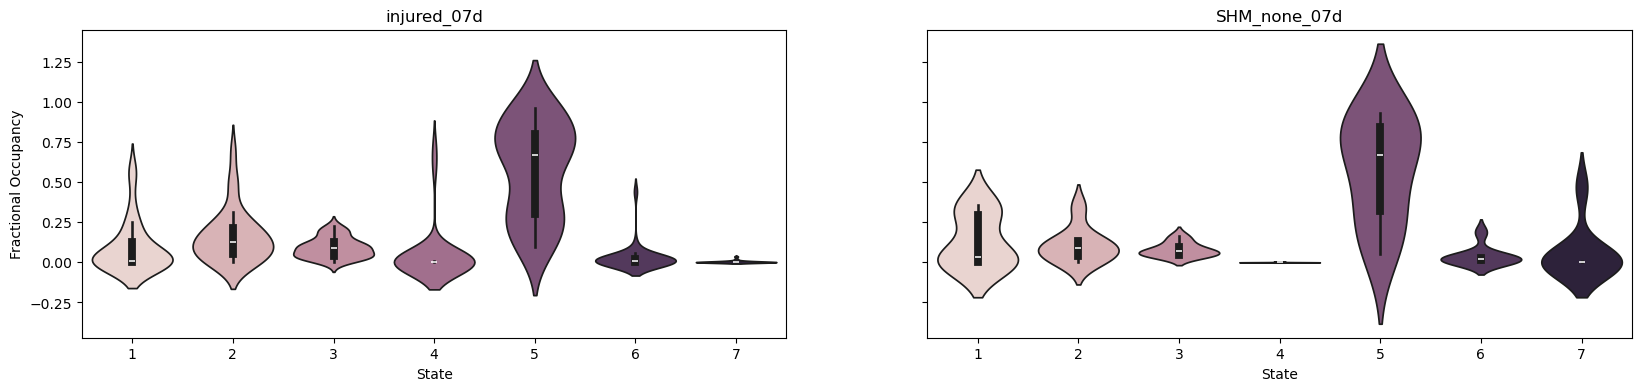

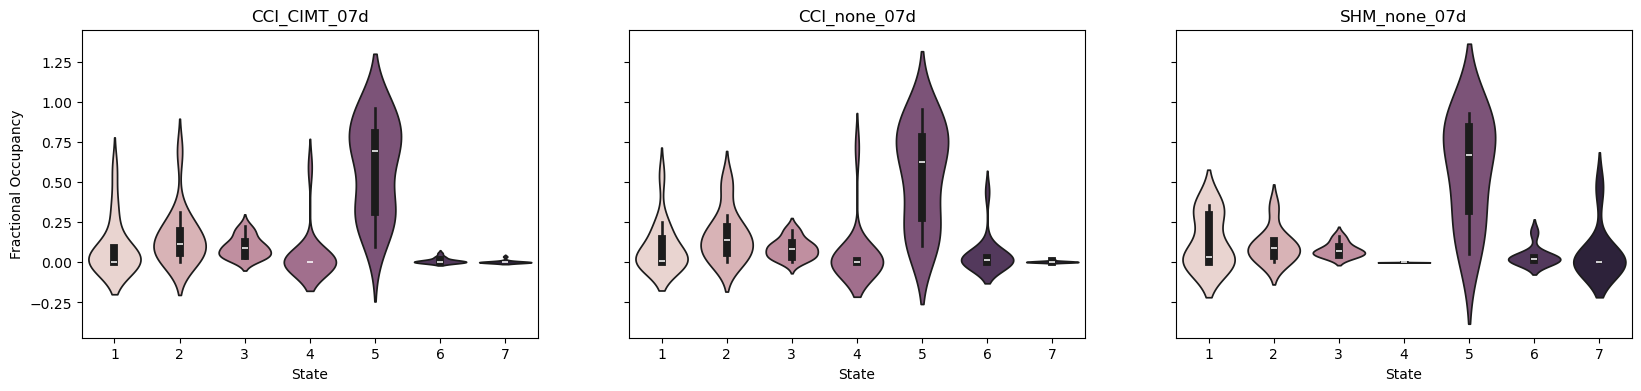

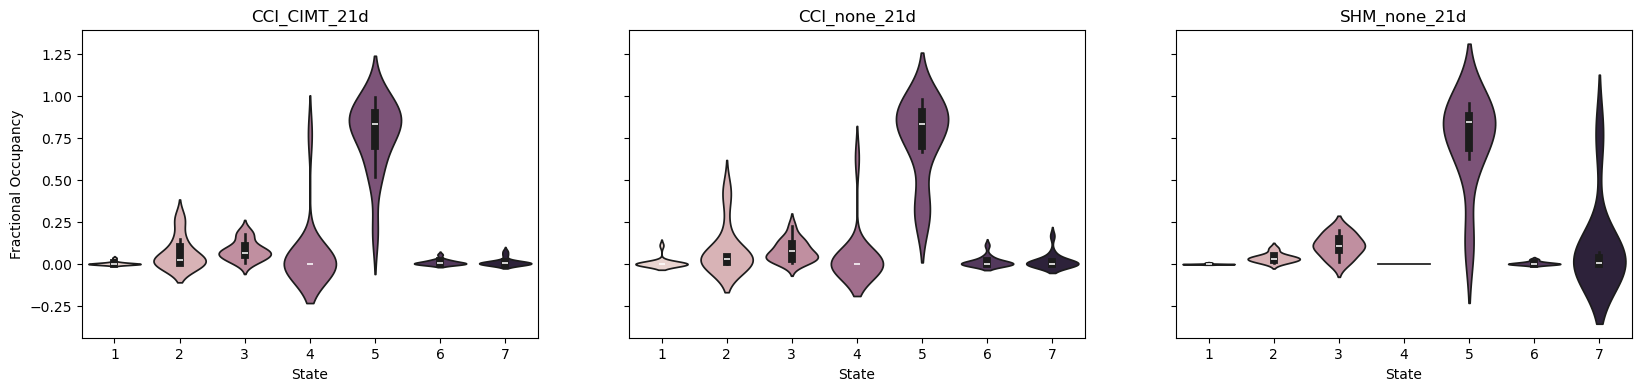

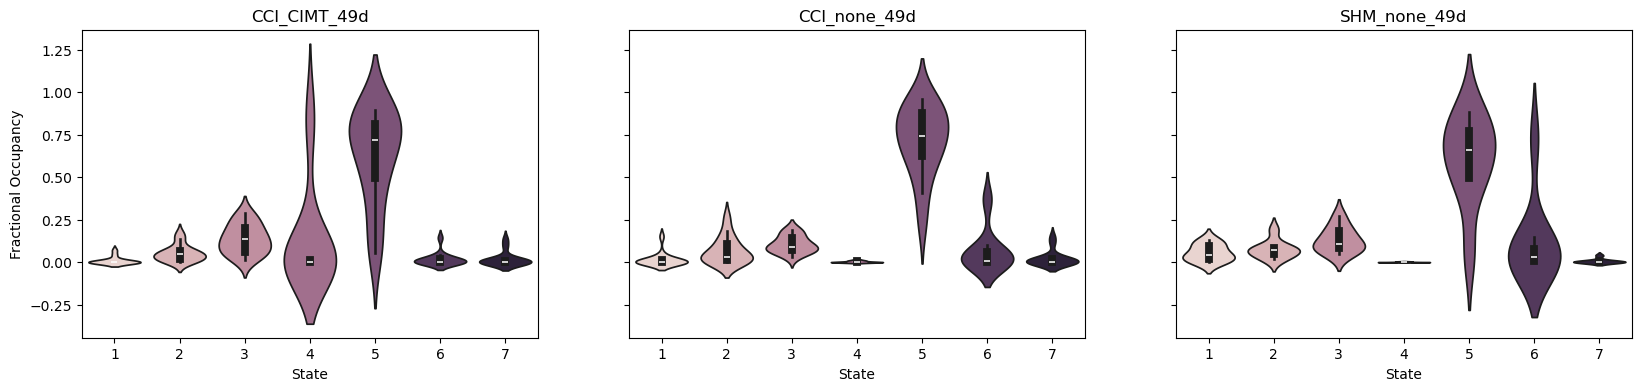

In [20]:
# FO means for each experimental group
for group in groups:
    groups[group]['fo'] = fo[np.where(y == group)]

print(sum([len(groups[group]['fo']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('fo', "Fractional Occupancy")

## Within-group mean state lifetimes

In [23]:
# State time course (STC) for each experimental group
for group in groups:
    groups[group]['stc'] = [stc[i] for i in range(len(stc)) if i in np.where(y == group)[0]]

print(sum([len(groups[group]['stc']) for group in groups]) == full_data.n_sessions)

True


True


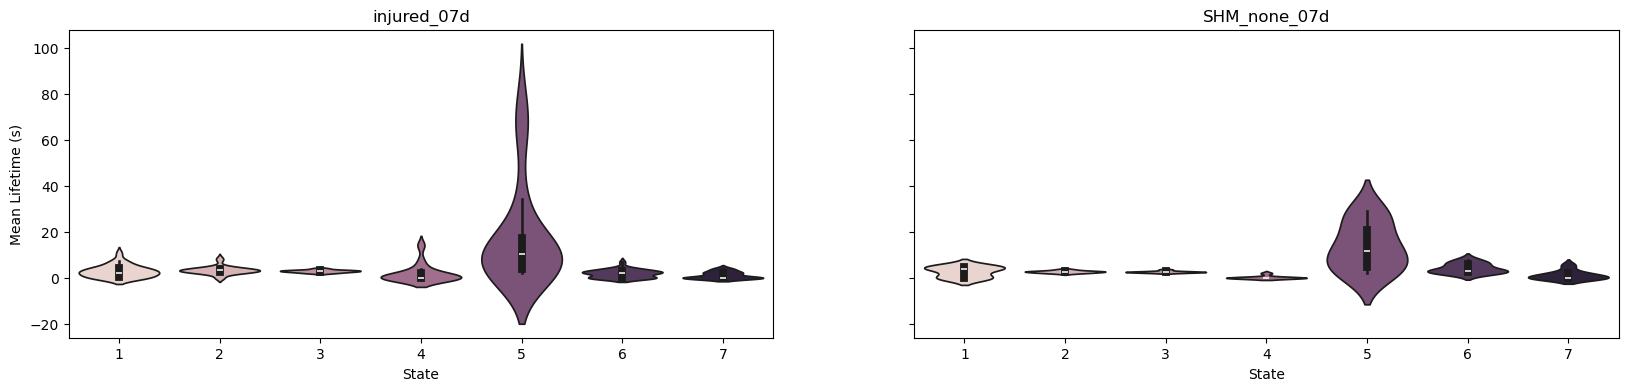

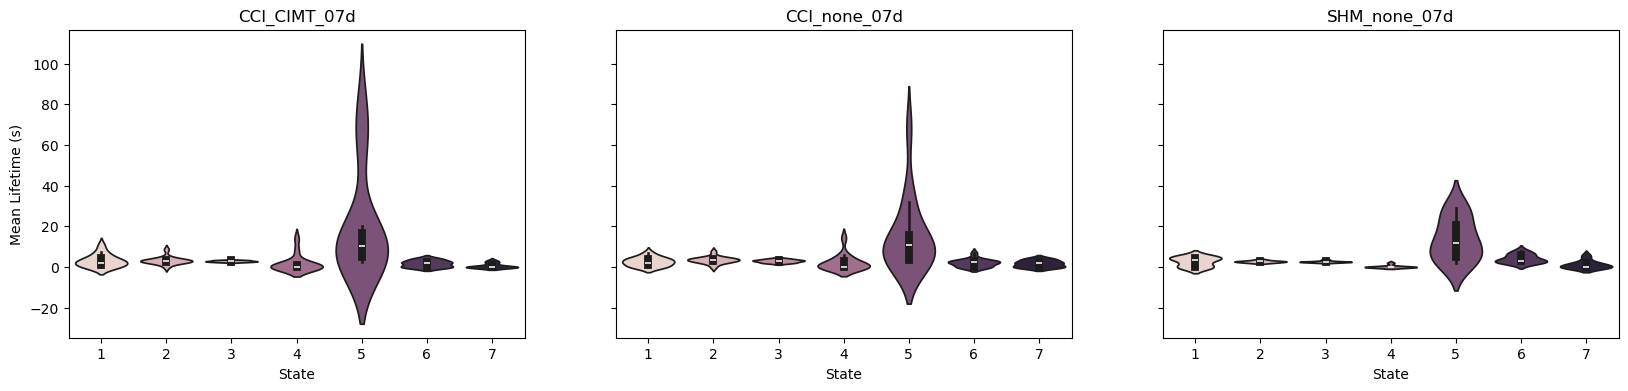

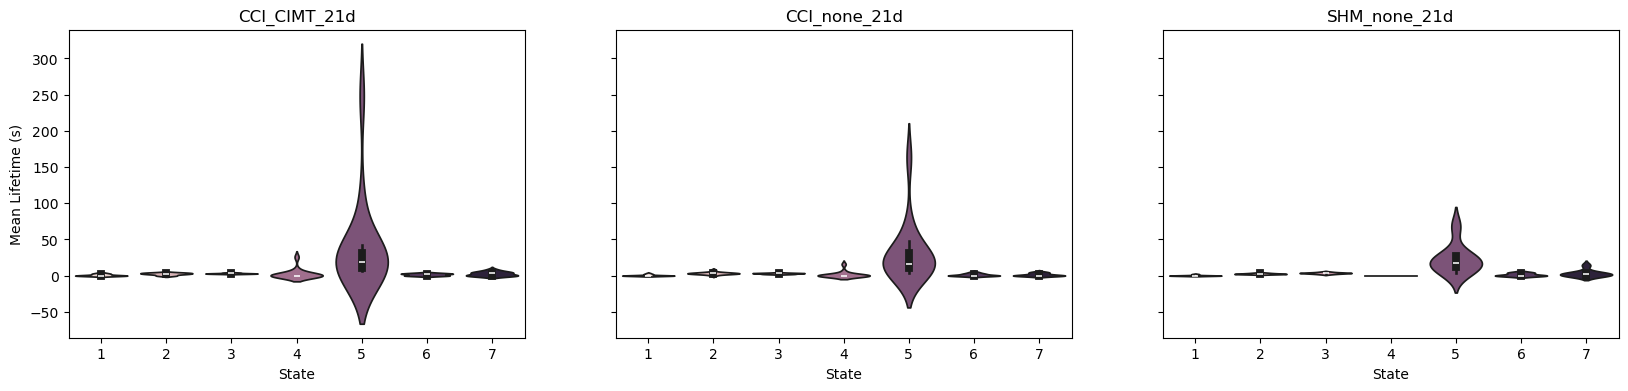

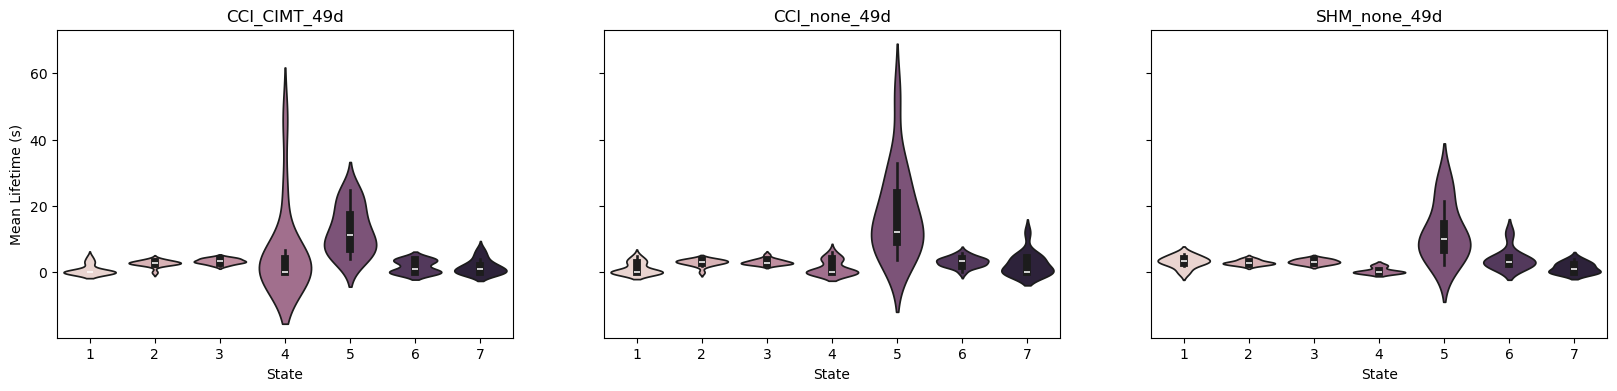

In [24]:
# Calculate mean lifetimes (in seconds) for each experimental group
for group in groups:
    groups[group]['lt'] = modes.mean_lifetimes(groups[group]['stc'], sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

print(sum([len(groups[group]['lt']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('lt', "Mean Lifetime (s)")

## Within-group mean interstate intervals

True


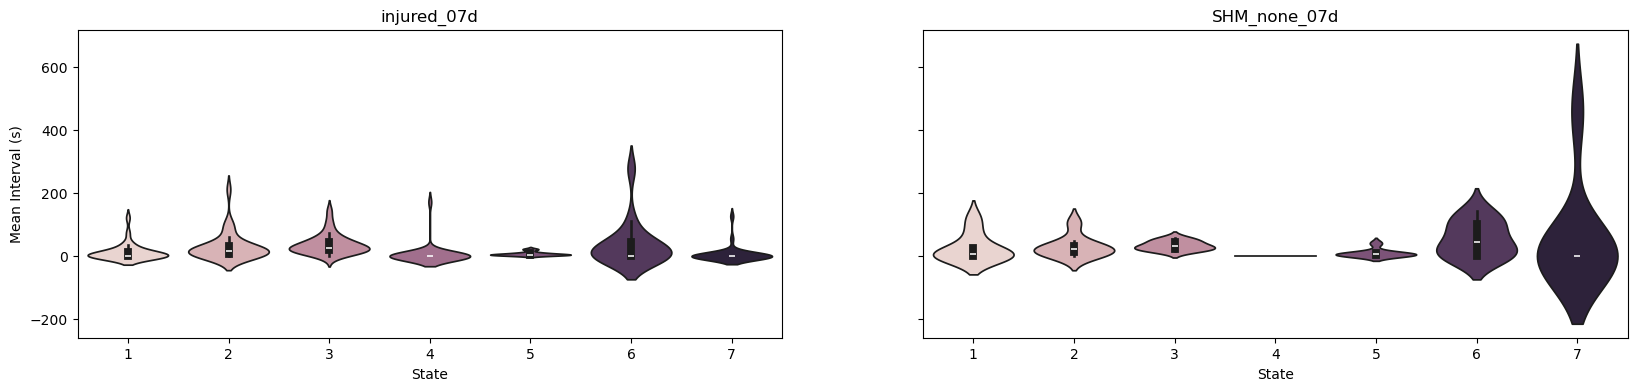

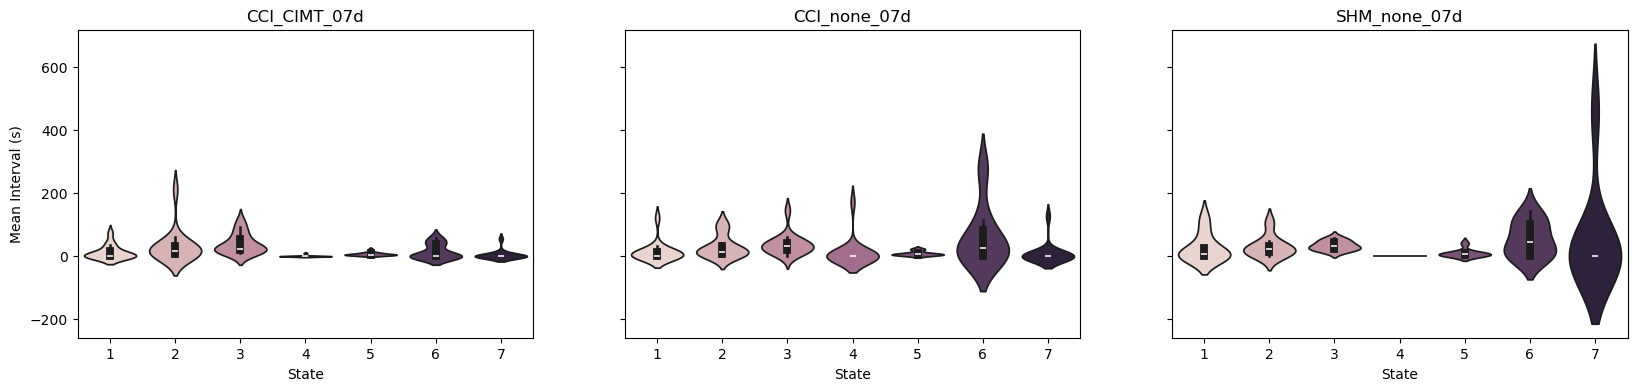

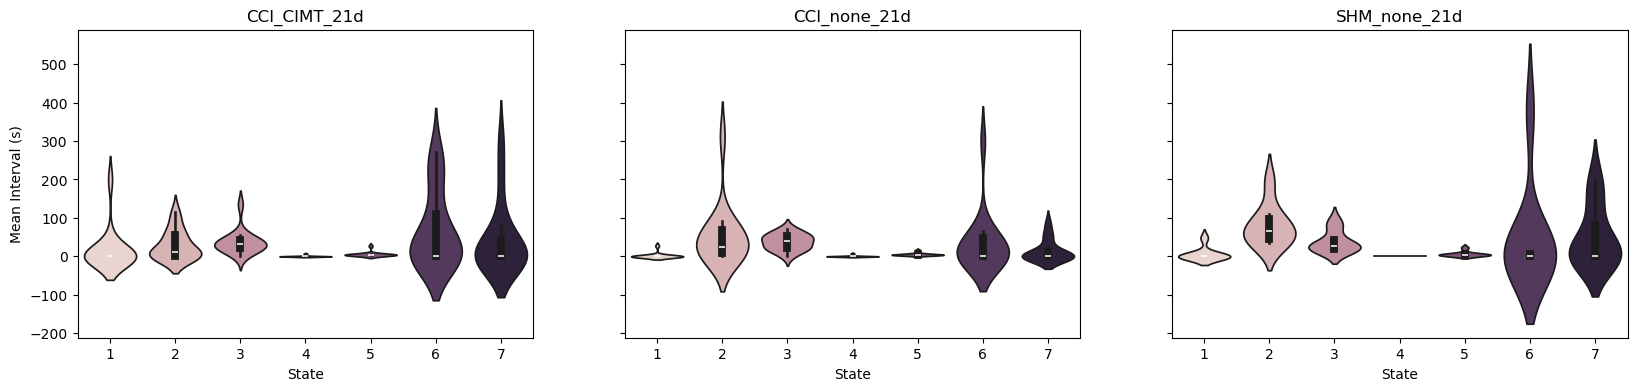

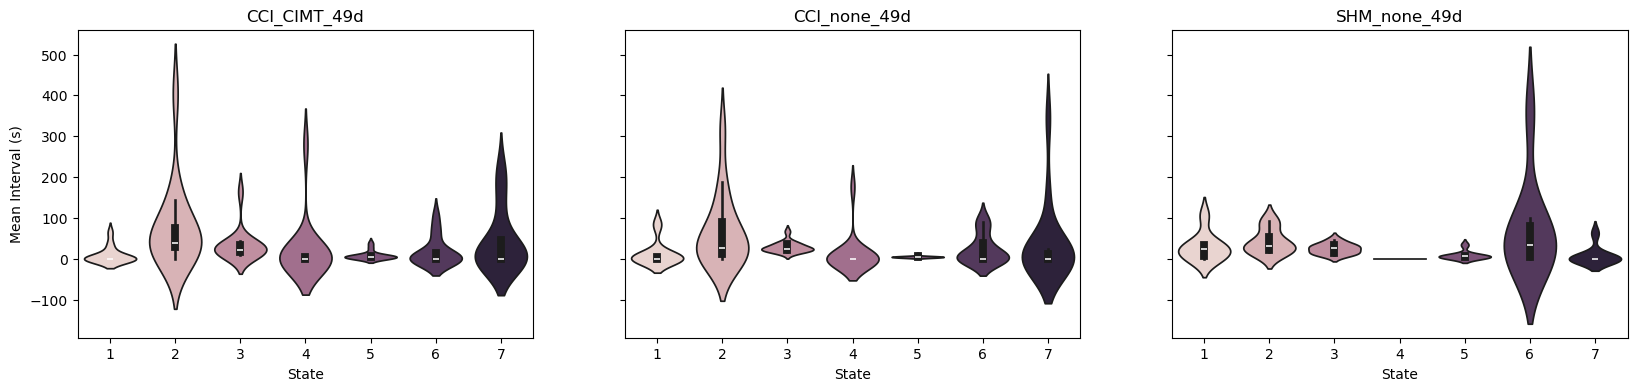

In [25]:
# Calculate mean intervals (in seconds) for each experimental group
for group in groups:
    groups[group]['intv'] = modes.mean_intervals(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['intv']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('intv', "Mean Interval (s)")

## Within-group switching rate 

True


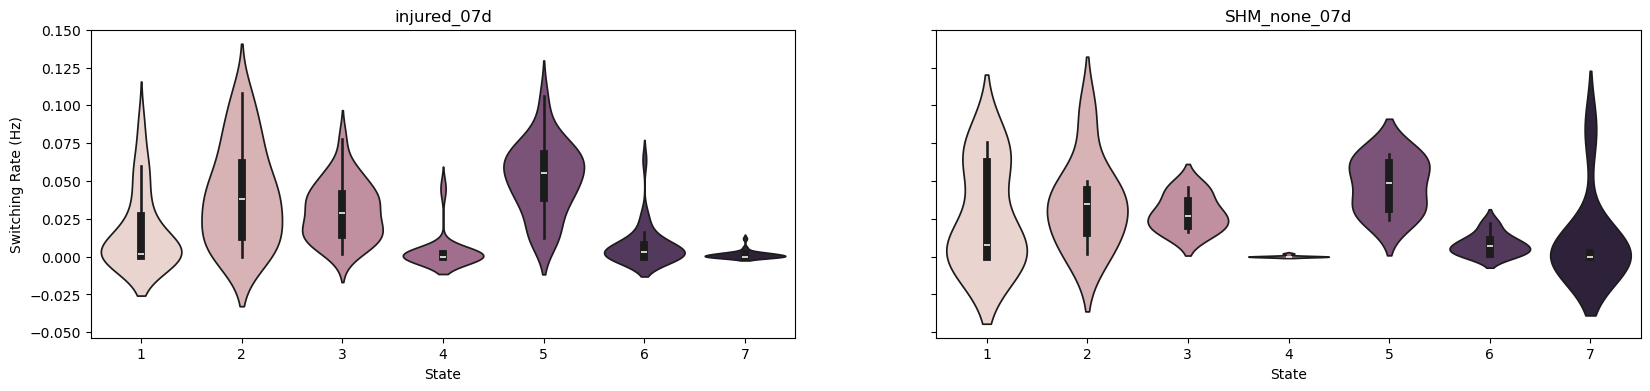

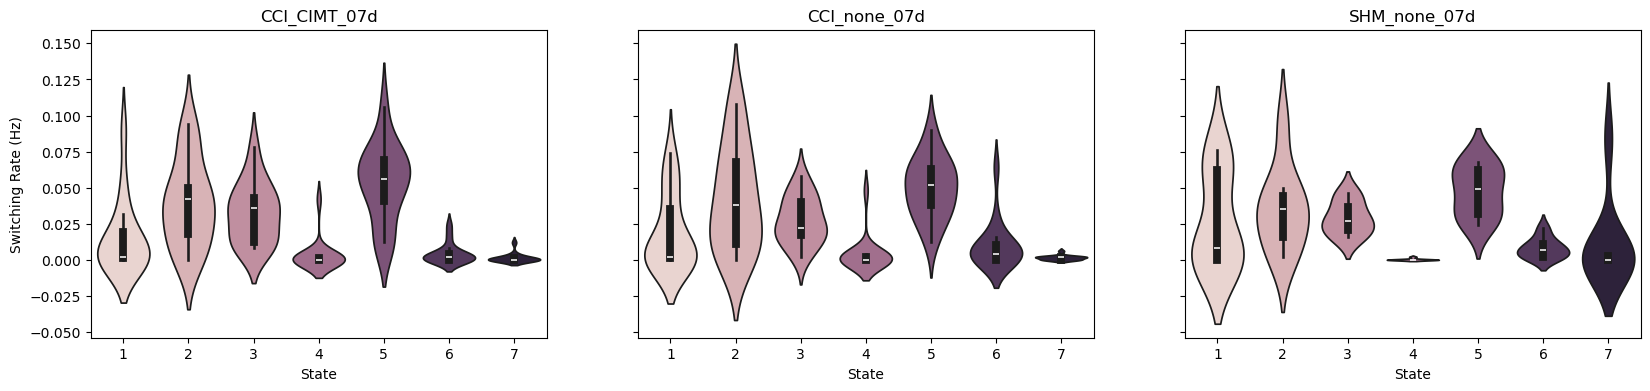

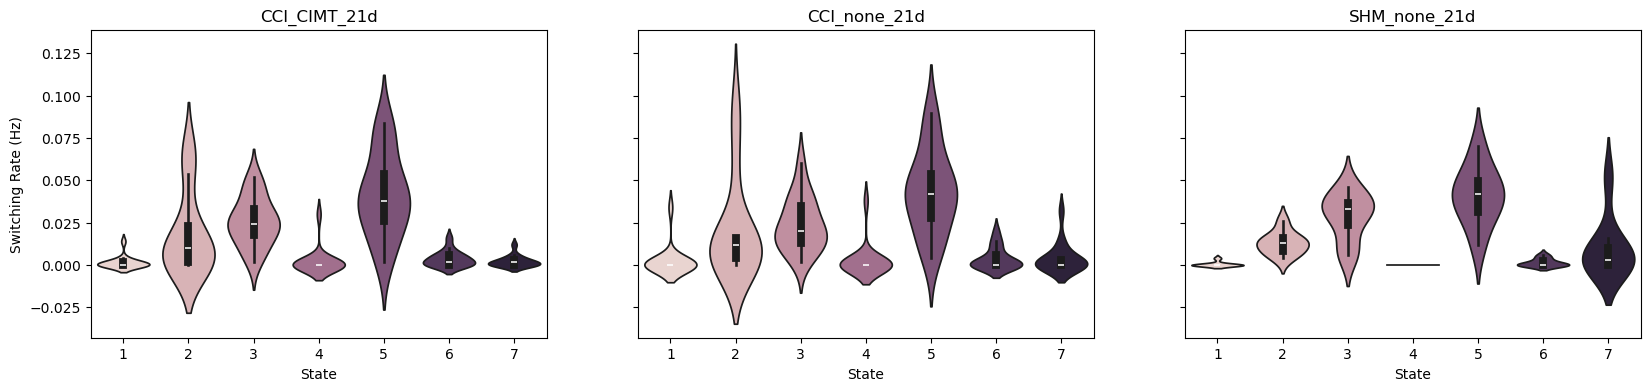

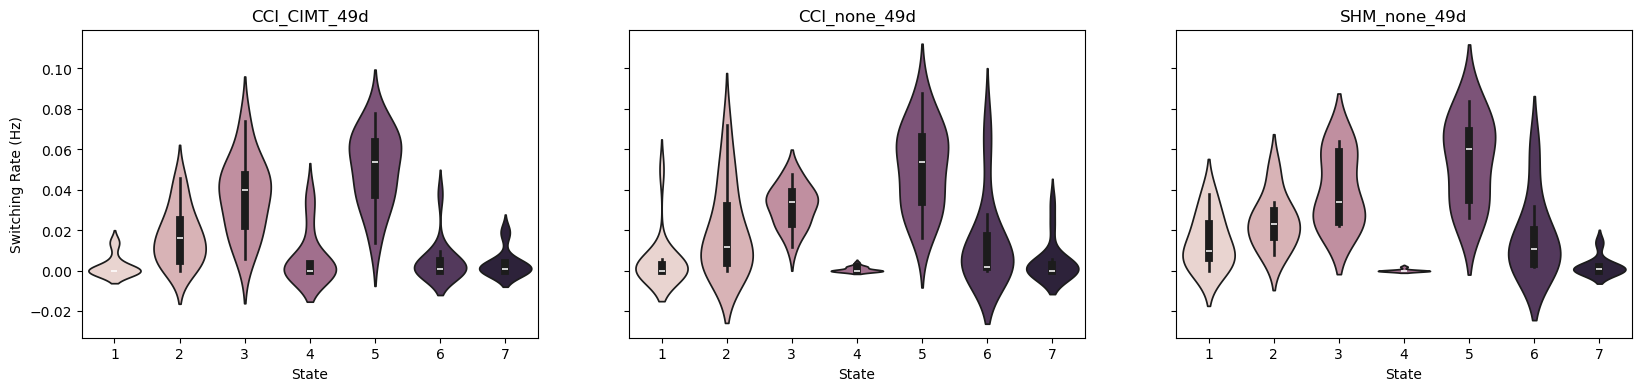

In [26]:
# Calculate the switching rate (Hz)
for group in groups:
    groups[group]['sr'] = modes.switching_rates(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['sr']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('sr', "Switching Rate (Hz)")

## Subject-Level Transition Probability Matrices

In [28]:
subj_trans_matrices = post_hoc.calc_trans_prob_matrix(list(stc), n_states=k_optimal)
subj_trans_matrices.shape

(113, 7, 7)

In [29]:
for group in groups:
    # Store transition matrices of all subjects in the group
    group_trans_matrices = subj_trans_matrices[np.where(y == group)]
    groups[group]['trans_matrices'] = group_trans_matrices
    print(group_trans_matrices.shape)
    
    # Store mean transition matrix of the group
    groups[group]['mean_trans_matrix'] = np.mean(group_trans_matrices, axis=0)
    print(groups[group]['mean_trans_matrix'].shape)

(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(14, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)


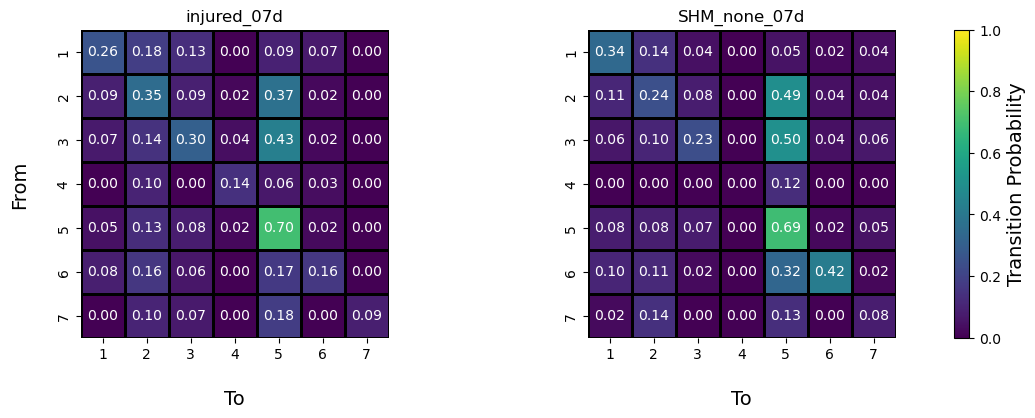

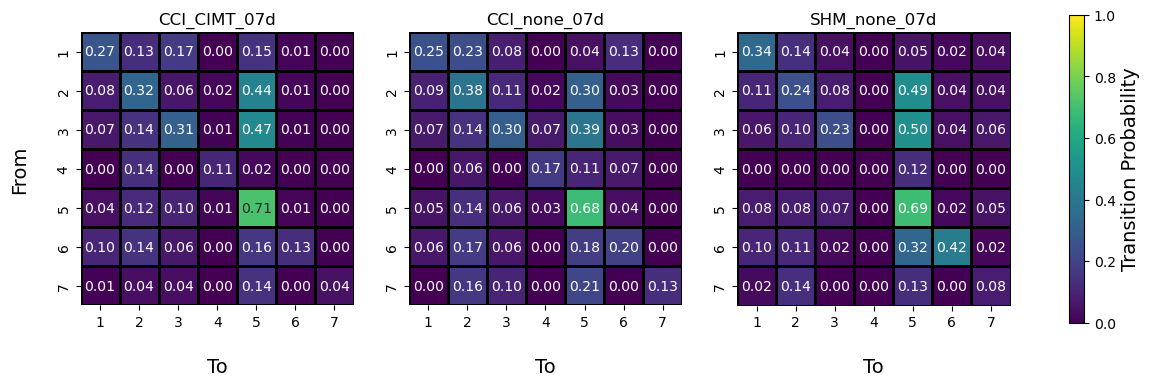

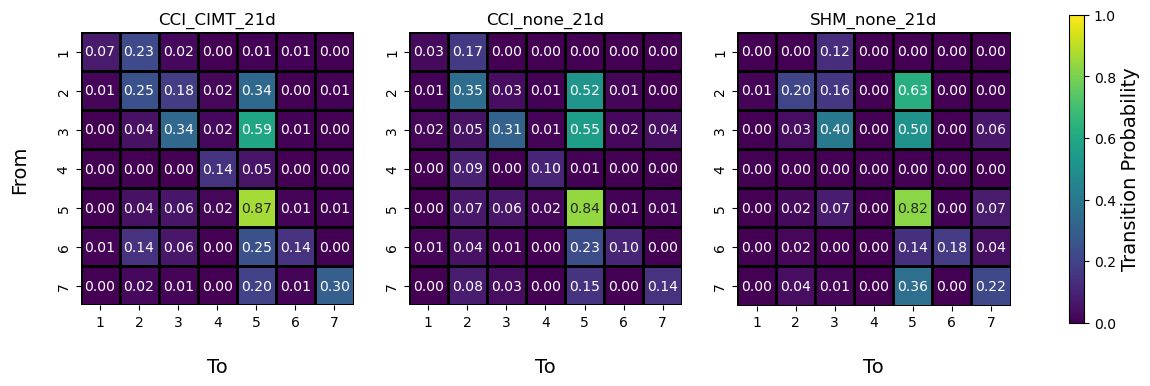

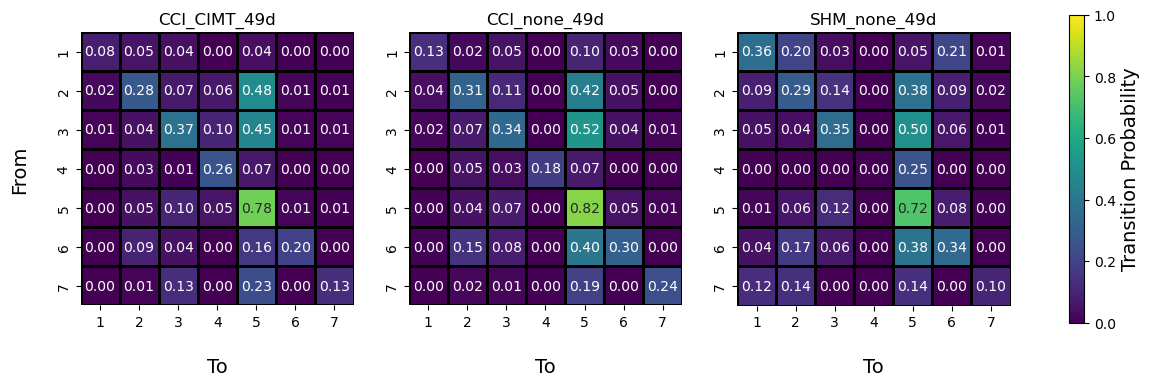

In [30]:
def heatmap_wrapper(data, ax):
    return sns.heatmap(
        data,
        cmap='viridis',
        linecolor='black',
        linewidths=1,
        cbar=False,
        annot=True,
        square=True,
        vmin=0,
        vmax=1,
        center=0.5,
        fmt='.2f',
        ax=ax,
    )

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
im = heatmap_wrapper(np.mean(subj_trans_matrices[np.where((y == 'CCI_CIMT_07d') | (y == 'CCI_none_07d'))], axis=0), axs[0])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[0].set_title("injured_07d")

im = heatmap_wrapper(groups['SHM_none_07d']['mean_trans_matrix'], ax=axs[1])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[1].set_title('SHM_none_07d')

cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
cbar.set_label('Transition Probability', fontsize=14)
plt.show()

for PID in ['07d', '21d', '49d']:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im = heatmap_wrapper(groups['CCI_CIMT_' + PID]['mean_trans_matrix'], ax=axs[0])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[0].set_title("CCI_CIMT_" + PID)

    im = heatmap_wrapper(groups['CCI_none_' + PID]['mean_trans_matrix'], ax=axs[1])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[1].set_title("CCI_none_" + PID)
    
    im = heatmap_wrapper(groups['SHM_none_' + PID]['mean_trans_matrix'], ax=axs[2])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[2].set_title("SHM_none_" + PID)

    cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
    cbar.set_label('Transition Probability', fontsize=14)
    plt.show()

# Hypothesis Testing

In [32]:
ht_df = create_hypothesis_testing_dataframe(
    group_data=groups, 
    group_labels=list(np.unique(y)),
    metrics=['fo', 'lt', 'intv', 'sr'],
    k=k_optimal,
)
ht_df['subj'] = subj_order

tp_df = separate_trans_probs(
    group_data=groups, 
    group_labels=list(np.unique(y)),
    k=k_optimal,
)
tp_df['subj'] = subj_order

ht_df = ht_df.merge(tp_df, how='inner', on=['subj', 'group'])
ht_df = ht_df[[c for c in ht_df.columns if c not in ['subj', 'group']] + ['subj', 'group']] # reorder columns
ht_df['condition'] = ht_df['group'].map(lambda g: 'injured' if 'CCI' in g else 'healthy')
print(ht_df.shape)
print(ht_df.columns)
ht_df

(113, 80)
Index(['fo_state1', 'fo_state2', 'fo_state3', 'fo_state4', 'fo_state5',
       'fo_state6', 'fo_state7', 'lt_state1', 'lt_state2', 'lt_state3',
       'lt_state4', 'lt_state5', 'lt_state6', 'lt_state7', 'intv_state1',
       'intv_state2', 'intv_state3', 'intv_state4', 'intv_state5',
       'intv_state6', 'intv_state7', 'sr_state1', 'sr_state2', 'sr_state3',
       'sr_state4', 'sr_state5', 'sr_state6', 'sr_state7', 'tp_1to1',
       'tp_1to2', 'tp_1to3', 'tp_1to4', 'tp_1to5', 'tp_1to6', 'tp_1to7',
       'tp_2to1', 'tp_2to2', 'tp_2to3', 'tp_2to4', 'tp_2to5', 'tp_2to6',
       'tp_2to7', 'tp_3to1', 'tp_3to2', 'tp_3to3', 'tp_3to4', 'tp_3to5',
       'tp_3to6', 'tp_3to7', 'tp_4to1', 'tp_4to2', 'tp_4to3', 'tp_4to4',
       'tp_4to5', 'tp_4to6', 'tp_4to7', 'tp_5to1', 'tp_5to2', 'tp_5to3',
       'tp_5to4', 'tp_5to5', 'tp_5to6', 'tp_5to7', 'tp_6to1', 'tp_6to2',
       'tp_6to3', 'tp_6to4', 'tp_6to5', 'tp_6to6', 'tp_6to7', 'tp_7to1',
       'tp_7to2', 'tp_7to3', 'tp_7to4', 'tp_7to5

,fo_state1,fo_state2,fo_state3,fo_state4,fo_state5,fo_state6,fo_state7,lt_state1,lt_state2,lt_state3,...,tp_7to1,tp_7to2,tp_7to3,tp_7to4,tp_7to5,tp_7to6,tp_7to7,subj,group,condition
0,0.008,0.092,0.140,0.000,0.752,0.004,0.004,4.000000,3.285714,2.916667,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,CCI_CIMT_07d_001,CCI_CIMT_07d,injured
1,0.000,0.008,0.032,0.000,0.960,0.000,0.000,0.000000,2.000000,3.200000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d_004,CCI_CIMT_07d,injured
2,0.004,0.040,0.076,0.016,0.856,0.008,0.000,2.000000,2.500000,2.533333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d_006,CCI_CIMT_07d,injured
3,0.000,0.076,0.040,0.592,0.292,0.000,0.000,0.000000,3.454545,2.857143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d_007,CCI_CIMT_07d,injured
4,0.004,0.692,0.024,0.000,0.264,0.016,0.000,2.000000,8.650000,2.400000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CCI_CIMT_07d_010,CCI_CIMT_07d,injured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108,0.044,0.076,0.076,0.000,0.776,0.020,0.008,3.666667,4.222222,2.923077,...,0.0,0.0,0.0,0.0,0.5,0.0,0.5,SHM_none_49d_016,SHM_none_49d,healthy
109,0.000,0.016,0.088,0.004,0.884,0.008,0.000,0.000000,2.000000,3.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d_018,SHM_none_49d,healthy
110,0.088,0.088,0.180,0.000,0.496,0.148,0.000,3.384615,2.588235,3.103448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d_027,SHM_none_49d,healthy
111,0.132,0.032,0.048,0.000,0.060,0.728,0.000,3.473684,2.666667,2.181818,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,SHM_none_49d_028,SHM_none_49d,healthy


## Between Groups

### 07d

Note that CIMT treatment began after 07d

In [34]:
ht_df_07d = ht_df.loc[ht_df['group'].str.find('07d') != -1]
ht_df_07d['group'].unique()

array([np.str_('CCI_CIMT_07d'), np.str_('CCI_none_07d'),
       np.str_('SHM_none_07d')], dtype=object)

In [35]:
# FO
permtest_ind(
    data=ht_df_07d[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,healthy,injured,0.586486,0.538746,t-test,0.239727,0.007143,False
1,fo_state2,healthy,injured,-0.900538,0.392961,t-test,0.366110,0.007143,False
2,fo_state3,healthy,injured,-0.511712,0.635736,t-test,0.208143,0.007143,False
3,fo_state4,healthy,injured,-0.764431,0.268373,t-test,0.309376,0.007143,False
4,fo_state5,healthy,injured,0.066890,0.956104,t-test,0.027371,0.007143,False
5,fo_state6,healthy,injured,0.362650,0.511749,t-test,0.147602,0.007143,False
6,fo_state7,healthy,injured,0.960364,0.346365,welch,0.819452,0.007143,False


In [36]:
# State lifetimes
permtest_ind(
    data=ht_df_07d[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,healthy,injured,-0.188030,0.877712,t-test,0.076677,0.007143,False
1,lt_state2,healthy,injured,-1.042705,0.289371,t-test,0.422408,0.007143,False
2,lt_state3,healthy,injured,-1.372428,0.176182,t-test,0.558316,0.007143,False
3,lt_state4,healthy,injured,-2.256010,0.268373,welch,0.493106,0.007143,False
4,lt_state5,healthy,injured,-0.543939,0.650135,t-test,0.220673,0.007143,False
5,lt_state6,healthy,injured,3.194828,0.005399,t-test,1.309426,0.007143,True
6,lt_state7,healthy,injured,0.003902,0.962904,t-test,0.001602,0.007143,False


In [37]:
# Interstate intervals
permtest_ind(
    data=ht_df_07d[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,healthy,injured,1.074419,0.307369,t-test,0.443252,0.007143,False
1,intv_state2,healthy,injured,-0.016082,0.862514,t-test,0.006548,0.007143,False
2,intv_state3,healthy,injured,-0.391010,0.758524,t-test,0.158622,0.007143,False
3,intv_state4,healthy,injured,-0.557578,0.956504,t-test,0.225660,0.007143,False
4,intv_state5,healthy,injured,0.678690,0.482752,t-test,0.281572,0.007143,False
5,intv_state6,healthy,injured,0.554271,0.576742,t-test,0.225665,0.007143,False
6,intv_state7,healthy,injured,0.898648,0.236176,welch,0.733889,0.007143,False


In [38]:
# Switching rates
permtest_ind(
    data=ht_df_07d[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,healthy,injured,0.903979,0.385361,t-test,0.371112,0.007143,False
1,sr_state2,healthy,injured,-0.425487,0.695130,t-test,0.173539,0.007143,False
2,sr_state3,healthy,injured,-0.153720,0.921308,t-test,0.062466,0.007143,False
3,sr_state4,healthy,injured,-0.827461,0.375762,t-test,0.334900,0.007143,False
4,sr_state5,healthy,injured,-0.475734,0.647135,t-test,0.193636,0.007143,False
5,sr_state6,healthy,injured,0.191861,0.697530,t-test,0.077896,0.007143,False
6,sr_state7,healthy,injured,0.945715,0.312169,welch,0.798586,0.007143,False


In [39]:
# Transition probabilities
permtest_ind(
    data=ht_df_07d[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,healthy,injured,0.655088,0.528747,t-test,0.267506,0.00102,False
1,tp_1to2,healthy,injured,-0.395934,0.803920,t-test,0.160624,0.00102,False
2,tp_1to3,healthy,injured,-0.809975,0.648535,t-test,0.327968,0.00102,False
3,tp_1to4,healthy,injured,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,healthy,injured,-0.615277,0.696130,t-test,0.249334,0.00102,False
5,tp_1to6,healthy,injured,-0.662814,0.683132,t-test,0.268339,0.00102,False
6,tp_1to7,healthy,injured,0.969685,0.427957,welch,0.825230,0.00102,False
7,tp_2to1,healthy,injured,0.434013,0.643336,t-test,0.176987,0.00102,False
8,tp_2to2,healthy,injured,-1.310589,0.188581,t-test,0.532670,0.00102,False
9,tp_2to3,healthy,injured,-0.191459,0.940906,t-test,0.077915,0.00102,False


### 21d

#### CCI Only

In [41]:
ht_df_21d_CCI = ht_df.loc[(ht_df['group'].str.find('21d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_21d_CCI['group'].unique()

array([np.str_('CCI_CIMT_21d'), np.str_('CCI_none_21d')], dtype=object)

In [42]:
# FO
permtest_ind(
    data=ht_df_21d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_21d,CCI_none_21d,-0.476723,0.974103,t-test,0.180185,0.007143,False
1,fo_state2,CCI_CIMT_21d,CCI_none_21d,-0.488925,0.647135,t-test,0.184796,0.007143,False
2,fo_state3,CCI_CIMT_21d,CCI_none_21d,0.133767,0.898710,t-test,0.050559,0.007143,False
3,fo_state4,CCI_CIMT_21d,CCI_none_21d,0.148613,0.690931,t-test,0.056170,0.007143,False
4,fo_state5,CCI_CIMT_21d,CCI_none_21d,0.281425,0.776122,t-test,0.106369,0.007143,False
5,fo_state6,CCI_CIMT_21d,CCI_none_21d,-0.452238,0.742126,t-test,0.170930,0.007143,False
6,fo_state7,CCI_CIMT_21d,CCI_none_21d,-0.516559,0.702130,t-test,0.195241,0.007143,False


In [43]:
# State lifetimes
permtest_ind(
    data=ht_df_21d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_21d,CCI_none_21d,0.928743,0.386961,t-test,0.351032,0.007143,False
1,lt_state2,CCI_CIMT_21d,CCI_none_21d,-1.501924,0.148185,t-test,0.567674,0.007143,False
2,lt_state3,CCI_CIMT_21d,CCI_none_21d,0.208186,0.840316,t-test,0.078687,0.007143,False
3,lt_state4,CCI_CIMT_21d,CCI_none_21d,0.448905,0.690931,t-test,0.169670,0.007143,False
4,lt_state5,CCI_CIMT_21d,CCI_none_21d,0.412304,0.704930,t-test,0.155836,0.007143,False
5,lt_state6,CCI_CIMT_21d,CCI_none_21d,0.709959,0.467353,t-test,0.268339,0.007143,False
6,lt_state7,CCI_CIMT_21d,CCI_none_21d,1.367042,0.189981,t-test,0.516693,0.007143,False


In [44]:
# Interstate intervals
permtest_ind(
    data=ht_df_21d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_21d,CCI_none_21d,1.096377,0.483952,welch,0.414392,0.007143,False
1,intv_state2,CCI_CIMT_21d,CCI_none_21d,-1.054205,0.349365,t-test,0.398452,0.007143,False
2,intv_state3,CCI_CIMT_21d,CCI_none_21d,-0.107321,0.919508,t-test,0.040564,0.007143,False
3,intv_state4,CCI_CIMT_21d,CCI_none_21d,-0.065824,1.000000,t-test,0.024879,0.007143,False
4,intv_state5,CCI_CIMT_21d,CCI_none_21d,0.197304,0.878312,t-test,0.074574,0.007143,False
5,intv_state6,CCI_CIMT_21d,CCI_none_21d,1.086639,0.287971,t-test,0.410711,0.007143,False
6,intv_state7,CCI_CIMT_21d,CCI_none_21d,1.241762,0.260974,welch,0.469342,0.007143,False


In [45]:
# Switching rates
permtest_ind(
    data=ht_df_21d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_21d,CCI_none_21d,-0.382044,0.967903,t-test,0.144399,0.007143,False
1,sr_state2,CCI_CIMT_21d,CCI_none_21d,-0.295945,0.777922,t-test,0.111857,0.007143,False
2,sr_state3,CCI_CIMT_21d,CCI_none_21d,0.291964,0.775722,t-test,0.110352,0.007143,False
3,sr_state4,CCI_CIMT_21d,CCI_none_21d,-0.166091,0.855314,t-test,0.062776,0.007143,False
4,sr_state5,CCI_CIMT_21d,CCI_none_21d,-0.224878,0.831317,t-test,0.084996,0.007143,False
5,sr_state6,CCI_CIMT_21d,CCI_none_21d,-0.130347,0.954905,t-test,0.049266,0.007143,False
6,sr_state7,CCI_CIMT_21d,CCI_none_21d,-0.829140,0.529347,t-test,0.313385,0.007143,False


In [46]:
# Transition probabilities
permtest_ind(
    data=ht_df_21d_CCI[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_21d,CCI_none_21d,0.893500,0.460554,t-test,0.337711,0.00102,False
1,tp_1to2,CCI_CIMT_21d,CCI_none_21d,0.434210,0.718328,t-test,0.164116,0.00102,False
2,tp_1to3,CCI_CIMT_21d,CCI_none_21d,0.883452,0.990101,t-test,0.333914,0.00102,False
3,tp_1to4,CCI_CIMT_21d,CCI_none_21d,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,CCI_CIMT_21d,CCI_none_21d,0.632456,1.000000,t-test,0.239046,0.00102,False
5,tp_1to6,CCI_CIMT_21d,CCI_none_21d,1.000000,1.000000,welch,0.377964,0.00102,False
6,tp_1to7,CCI_CIMT_21d,CCI_none_21d,NaN,0.000200,welch,NaN,0.00102,True
7,tp_2to1,CCI_CIMT_21d,CCI_none_21d,0.770679,0.498550,t-test,0.291289,0.00102,False
8,tp_2to2,CCI_CIMT_21d,CCI_none_21d,-1.328764,0.193181,t-test,0.502225,0.00102,False
9,tp_2to3,CCI_CIMT_21d,CCI_none_21d,2.033710,0.022398,welch,0.768670,0.00102,False


### 49d

#### CCI Only

In [49]:
ht_df_49d_CCI = ht_df.loc[(ht_df['group'].str.find('49d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_49d_CCI['group'].unique()

array([np.str_('CCI_CIMT_49d'), np.str_('CCI_none_49d')], dtype=object)

In [50]:
# FO
permtest_ind(
    data=ht_df_49d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_49d,CCI_none_49d,-0.524134,0.694131,t-test,0.201722,0.007143,False
1,fo_state2,CCI_CIMT_49d,CCI_none_49d,-0.634193,0.546345,t-test,0.244111,0.007143,False
2,fo_state3,CCI_CIMT_49d,CCI_none_49d,1.213143,0.241576,t-test,0.467514,0.007143,False
3,fo_state4,CCI_CIMT_49d,CCI_none_49d,1.674015,0.148185,welch,0.669095,0.007143,False
4,fo_state5,CCI_CIMT_49d,CCI_none_49d,-1.003663,0.333367,t-test,0.386682,0.007143,False
5,fo_state6,CCI_CIMT_49d,CCI_none_49d,-1.560310,0.163584,welch,0.582813,0.007143,False
6,fo_state7,CCI_CIMT_49d,CCI_none_49d,-0.233098,0.770123,t-test,0.089761,0.007143,False


In [51]:
# State lifetimes
permtest_ind(
    data=ht_df_49d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_49d,CCI_none_49d,-0.701978,0.515748,t-test,0.270297,0.007143,False
1,lt_state2,CCI_CIMT_49d,CCI_none_49d,-0.623788,0.534347,t-test,0.240211,0.007143,False
2,lt_state3,CCI_CIMT_49d,CCI_none_49d,0.581426,0.584742,t-test,0.223900,0.007143,False
3,lt_state4,CCI_CIMT_49d,CCI_none_49d,1.329929,0.249775,welch,0.530500,0.007143,False
4,lt_state5,CCI_CIMT_49d,CCI_none_49d,-1.307887,0.214579,t-test,0.503350,0.007143,False
5,lt_state6,CCI_CIMT_49d,CCI_none_49d,-2.270429,0.030397,t-test,0.874635,0.007143,False
6,lt_state7,CCI_CIMT_49d,CCI_none_49d,-0.661211,0.521948,t-test,0.254522,0.007143,False


In [52]:
# Interstate intervals
permtest_ind(
    data=ht_df_49d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_49d,CCI_none_49d,-0.434756,0.725527,t-test,0.167357,0.007143,False
1,intv_state2,CCI_CIMT_49d,CCI_none_49d,0.336006,0.736126,t-test,0.129432,0.007143,False
2,intv_state3,CCI_CIMT_49d,CCI_none_49d,0.423883,0.850315,t-test,0.163421,0.007143,False
3,intv_state4,CCI_CIMT_49d,CCI_none_49d,0.459954,0.521748,t-test,0.177246,0.007143,False
4,intv_state5,CCI_CIMT_49d,CCI_none_49d,1.256342,0.290171,welch,0.500278,0.007143,False
5,intv_state6,CCI_CIMT_49d,CCI_none_49d,-0.423916,0.658934,t-test,0.163257,0.007143,False
6,intv_state7,CCI_CIMT_49d,CCI_none_49d,0.206463,0.835516,t-test,0.079494,0.007143,False


In [53]:
# Switching rates
permtest_ind(
    data=ht_df_49d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_49d,CCI_none_49d,-0.643432,0.733527,t-test,0.247581,0.007143,False
1,sr_state2,CCI_CIMT_49d,CCI_none_49d,-0.490689,0.644536,t-test,0.188874,0.007143,False
2,sr_state3,CCI_CIMT_49d,CCI_none_49d,0.890257,0.385561,welch,0.349768,0.007143,False
3,sr_state4,CCI_CIMT_49d,CCI_none_49d,1.751304,0.137986,welch,0.699505,0.007143,False
4,sr_state5,CCI_CIMT_49d,CCI_none_49d,-0.068132,0.937506,t-test,0.026235,0.007143,False
5,sr_state6,CCI_CIMT_49d,CCI_none_49d,-1.598307,0.143386,welch,0.600649,0.007143,False
6,sr_state7,CCI_CIMT_49d,CCI_none_49d,-0.300087,0.803520,t-test,0.115517,0.007143,False


In [54]:
# Transition probabilities
permtest_ind(
    data=ht_df_49d_CCI[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/miniforge3/envs/osld/lib/python3.12/site-packages/scipy/stats/_morestats.py:3326: RuntimeWarning: invalid value encountered in divide
  W = numer / denom
/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:189: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean/s_pooled


,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_49d,CCI_none_49d,-0.698656,0.502750,t-test,0.269015,0.00102,False
1,tp_1to2,CCI_CIMT_49d,CCI_none_49d,0.786167,0.619538,t-test,0.303038,0.00102,False
2,tp_1to3,CCI_CIMT_49d,CCI_none_49d,-0.170796,0.856914,t-test,0.065791,0.00102,False
3,tp_1to4,CCI_CIMT_49d,CCI_none_49d,NaN,0.000200,welch,NaN,0.00102,True
4,tp_1to5,CCI_CIMT_49d,CCI_none_49d,-1.322359,0.246975,welch,0.497851,0.00102,False
5,tp_1to6,CCI_CIMT_49d,CCI_none_49d,-1.461417,0.503950,welch,0.542411,0.00102,False
6,tp_1to7,CCI_CIMT_49d,CCI_none_49d,NaN,0.000200,welch,NaN,0.00102,True
7,tp_2to1,CCI_CIMT_49d,CCI_none_49d,-0.696111,0.543946,t-test,0.267926,0.00102,False
8,tp_2to2,CCI_CIMT_49d,CCI_none_49d,-0.627801,0.533947,t-test,0.241730,0.00102,False
9,tp_2to3,CCI_CIMT_49d,CCI_none_49d,-0.922738,0.383762,t-test,0.355164,0.00102,False


## Longitudinal

### 21d vs. 07d

#### CCI_CIMT

In [57]:
ht_df_21v7_CCI_CIMT = ht_df.loc[(ht_df['group'] == 'CCI_CIMT_21d') | (ht_df['group'] == 'CCI_CIMT_07d')]
ht_df_21v7_CCI_CIMT['group'].unique()

array([np.str_('CCI_CIMT_07d'), np.str_('CCI_CIMT_21d')], dtype=object)

In [58]:
# FO
permtest_rel(
    data=ht_df_21v7_CCI_CIMT[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_07d,CCI_CIMT_21d,0.090933,0.033797,0.777959,0.007143,False
1,fo_state2,CCI_CIMT_07d,CCI_CIMT_21d,0.090400,0.066993,0.669105,0.007143,False
2,fo_state3,CCI_CIMT_07d,CCI_CIMT_21d,0.012533,0.487151,0.212936,0.007143,False
3,fo_state4,CCI_CIMT_07d,CCI_CIMT_21d,-0.012000,0.792121,0.070084,0.007143,False
4,fo_state5,CCI_CIMT_07d,CCI_CIMT_21d,-0.172800,0.095390,0.700885,0.007143,False
5,fo_state6,CCI_CIMT_07d,CCI_CIMT_21d,0.000000,1.000000,0.000000,0.007143,False
6,fo_state7,CCI_CIMT_07d,CCI_CIMT_21d,-0.009067,0.044196,0.554479,0.007143,False


In [59]:
# State lifetimes
permtest_rel(
    data=ht_df_21v7_CCI_CIMT[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_07d,CCI_CIMT_21d,2.249848,0.031997,0.972783,0.007143,False
1,lt_state2,CCI_CIMT_07d,CCI_CIMT_21d,0.755128,0.185981,0.465462,0.007143,False
2,lt_state3,CCI_CIMT_07d,CCI_CIMT_21d,-0.191665,0.285771,0.397905,0.007143,False
3,lt_state4,CCI_CIMT_07d,CCI_CIMT_21d,-0.775873,0.805119,0.143864,0.007143,False
4,lt_state5,CCI_CIMT_07d,CCI_CIMT_21d,-18.735896,0.286771,0.407184,0.007143,False
5,lt_state6,CCI_CIMT_07d,CCI_CIMT_21d,0.046667,0.947905,0.031340,0.007143,False
6,lt_state7,CCI_CIMT_07d,CCI_CIMT_21d,-2.000000,0.026597,0.936282,0.007143,False


In [60]:
# Interstate intervals
permtest_rel(
    data=ht_df_21v7_CCI_CIMT[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_07d,CCI_CIMT_21d,-4.211709,0.885711,0.108577,0.007143,False
1,intv_state2,CCI_CIMT_07d,CCI_CIMT_21d,2.108036,0.893711,0.047835,0.007143,False
2,intv_state3,CCI_CIMT_07d,CCI_CIMT_21d,2.822874,0.732927,0.093491,0.007143,False
3,intv_state4,CCI_CIMT_07d,CCI_CIMT_21d,0.200000,1.000000,0.092892,0.007143,False
4,intv_state5,CCI_CIMT_07d,CCI_CIMT_21d,1.431774,0.546945,0.265363,0.007143,False
5,intv_state6,CCI_CIMT_07d,CCI_CIMT_21d,-54.629437,0.061594,0.793740,0.007143,False
6,intv_state7,CCI_CIMT_07d,CCI_CIMT_21d,-40.373333,0.129187,0.640168,0.007143,False


In [61]:
# Switching rates
permtest_rel(
    data=ht_df_21v7_CCI_CIMT[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_07d,CCI_CIMT_21d,0.014000,0.055194,0.795181,0.007143,False
1,sr_state2,CCI_CIMT_07d,CCI_CIMT_21d,0.020400,0.044796,0.782529,0.007143,False
2,sr_state3,CCI_CIMT_07d,CCI_CIMT_21d,0.006800,0.248575,0.395218,0.007143,False
3,sr_state4,CCI_CIMT_07d,CCI_CIMT_21d,0.000933,0.755124,0.103209,0.007143,False
4,sr_state5,CCI_CIMT_07d,CCI_CIMT_21d,0.012000,0.092191,0.490516,0.007143,False
5,sr_state6,CCI_CIMT_07d,CCI_CIMT_21d,0.000533,0.876912,0.093994,0.007143,False
6,sr_state7,CCI_CIMT_07d,CCI_CIMT_21d,-0.000933,0.240576,0.299025,0.007143,False


In [62]:
# Transition probabilities
permtest_rel(
    data=ht_df_21v7_CCI_CIMT[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_07d,CCI_CIMT_21d,0.197215,0.084792,0.812745,0.00102,False
1,tp_1to2,CCI_CIMT_07d,CCI_CIMT_21d,-0.094375,0.428757,0.307611,0.00102,False
2,tp_1to3,CCI_CIMT_07d,CCI_CIMT_21d,0.152507,0.007799,0.633173,0.00102,False
3,tp_1to4,CCI_CIMT_07d,CCI_CIMT_21d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_CIMT_07d,CCI_CIMT_21d,0.139375,0.009199,0.739810,0.00102,False
5,tp_1to6,CCI_CIMT_07d,CCI_CIMT_21d,0.002963,1.000000,0.107019,0.00102,False
6,tp_1to7,CCI_CIMT_07d,CCI_CIMT_21d,0.002315,0.993701,0.377964,0.00102,False
7,tp_2to1,CCI_CIMT_07d,CCI_CIMT_21d,0.067970,0.079792,0.718869,0.00102,False
8,tp_2to2,CCI_CIMT_07d,CCI_CIMT_21d,0.073609,0.342766,0.340733,0.00102,False
9,tp_2to3,CCI_CIMT_07d,CCI_CIMT_21d,-0.115592,0.091591,0.601920,0.00102,False


#### CCI_none

In [63]:
ht_df_21v7_CCI_none = ht_df.loc[(ht_df['group'] == 'CCI_none_21d') | (ht_df['group'] == 'CCI_none_07d')]
ht_df_21v7_CCI_none['group'].unique()

array([np.str_('CCI_none_07d'), np.str_('CCI_none_21d')], dtype=object)

In [64]:
# FO
permtest_rel(
    data=ht_df_21v7_CCI_none[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_none_07d,CCI_none_21d,0.085333,0.030397,0.814444,0.007143,False
1,fo_state2,CCI_none_07d,CCI_none_21d,0.079200,0.117588,0.546110,0.007143,False
2,fo_state3,CCI_none_07d,CCI_none_21d,0.008000,0.775322,0.132678,0.007143,False
3,fo_state4,CCI_none_07d,CCI_none_21d,0.007467,0.526147,0.044457,0.007143,False
4,fo_state5,CCI_none_07d,CCI_none_21d,-0.197067,0.055394,0.738789,0.007143,False
5,fo_state6,CCI_none_07d,CCI_none_21d,0.032267,0.419558,0.406116,0.007143,False
6,fo_state7,CCI_none_07d,CCI_none_21d,-0.015200,0.279172,0.492130,0.007143,False


In [65]:
# State lifetimes
permtest_rel(
    data=ht_df_21v7_CCI_none[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_none_07d,CCI_none_21d,2.182271,0.002800,1.318254,0.007143,True
1,lt_state2,CCI_none_07d,CCI_none_21d,0.136838,0.829317,0.083437,0.007143,False
2,lt_state3,CCI_none_07d,CCI_none_21d,-0.035826,0.907309,0.051138,0.007143,False
3,lt_state4,CCI_none_07d,CCI_none_21d,0.568000,0.666933,0.144536,0.007143,False
4,lt_state5,CCI_none_07d,CCI_none_21d,-16.029455,0.116788,0.530876,0.007143,False
5,lt_state6,CCI_none_07d,CCI_none_21d,0.846558,0.302770,0.481806,0.007143,False
6,lt_state7,CCI_none_07d,CCI_none_21d,0.260794,0.722528,0.149613,0.007143,False


In [66]:
# Interstate intervals
permtest_rel(
    data=ht_df_21v7_CCI_none[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_none_07d,CCI_none_21d,12.682540,0.117388,0.579685,0.007143,False
1,intv_state2,CCI_none_07d,CCI_none_21d,-22.968778,0.411759,0.393008,0.007143,False
2,intv_state3,CCI_none_07d,CCI_none_21d,-0.153483,0.997300,0.005636,0.007143,False
3,intv_state4,CCI_none_07d,CCI_none_21d,11.315497,0.765323,0.373264,0.007143,False
4,intv_state5,CCI_none_07d,CCI_none_21d,3.869708,0.101990,0.714631,0.007143,False
5,intv_state6,CCI_none_07d,CCI_none_21d,28.309014,0.401560,0.337145,0.007143,False
6,intv_state7,CCI_none_07d,CCI_none_21d,-6.000000,0.633937,0.204703,0.007143,False


In [67]:
# Switching rates
permtest_rel(
    data=ht_df_21v7_CCI_none[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_none_07d,CCI_none_21d,0.016800,0.041996,0.894720,0.007143,False
1,sr_state2,CCI_none_07d,CCI_none_21d,0.021067,0.097990,0.661192,0.007143,False
2,sr_state3,CCI_none_07d,CCI_none_21d,0.003200,0.633537,0.206064,0.007143,False
3,sr_state4,CCI_none_07d,CCI_none_21d,0.001200,0.543146,0.112220,0.007143,False
4,sr_state5,CCI_none_07d,CCI_none_21d,0.006800,0.288571,0.310020,0.007143,False
5,sr_state6,CCI_none_07d,CCI_none_21d,0.006400,0.256974,0.524097,0.007143,False
6,sr_state7,CCI_none_07d,CCI_none_21d,-0.002800,0.341166,0.461010,0.007143,False


In [68]:
# Transition probabilities
permtest_rel(
    data=ht_df_21v7_CCI_none[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_none_07d,CCI_none_21d,0.222308,0.023998,1.062196,0.00102,False
1,tp_1to2,CCI_none_07d,CCI_none_21d,0.064585,0.597940,0.189896,0.00102,False
2,tp_1to3,CCI_none_07d,CCI_none_21d,0.081114,0.053795,0.465705,0.00102,False
3,tp_1to4,CCI_none_07d,CCI_none_21d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_none_07d,CCI_none_21d,0.037387,0.050795,0.935839,0.00102,False
5,tp_1to6,CCI_none_07d,CCI_none_21d,0.127940,0.008199,0.683781,0.00102,False
6,tp_1to7,CCI_none_07d,CCI_none_21d,0.000000,1.000000,NaN,0.00102,False
7,tp_2to1,CCI_none_07d,CCI_none_21d,0.087303,0.006799,0.993488,0.00102,False
8,tp_2to2,CCI_none_07d,CCI_none_21d,0.027940,0.744926,0.131458,0.00102,False
9,tp_2to3,CCI_none_07d,CCI_none_21d,0.080884,0.030597,0.809779,0.00102,False


### 49d vs. 07d

#### CCI_CIMT

In [70]:
ht_df_49v7_CCI_CIMT = ht_df.loc[
    ((ht_df['group'] == 'CCI_CIMT_49d') | (ht_df['group'] == 'CCI_CIMT_07d'))
    & (ht_df['subj'] != 'CCI_CIMT_07d_006') # CCI_CIMT_49d_006 doesn't exist
]
ht_df_49v7_CCI_CIMT['group'].unique()

array([np.str_('CCI_CIMT_07d'), np.str_('CCI_CIMT_49d')], dtype=object)

In [71]:
# FO
permtest_rel(
    data=ht_df_49v7_CCI_CIMT[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_07d,CCI_CIMT_49d,0.092286,0.033197,0.766548,0.007143,False
1,fo_state2,CCI_CIMT_07d,CCI_CIMT_49d,0.113143,0.005799,0.900405,0.007143,True
2,fo_state3,CCI_CIMT_07d,CCI_CIMT_49d,-0.040000,0.210979,0.538358,0.007143,False
3,fo_state4,CCI_CIMT_07d,CCI_CIMT_49d,-0.098000,0.284972,0.416475,0.007143,False
4,fo_state5,CCI_CIMT_07d,CCI_CIMT_49d,-0.045429,0.643936,0.165174,0.007143,False
5,fo_state6,CCI_CIMT_07d,CCI_CIMT_49d,-0.006857,0.747725,0.239117,0.007143,False
6,fo_state7,CCI_CIMT_07d,CCI_CIMT_49d,-0.015143,0.291571,0.522770,0.007143,False


In [72]:
# State lifetimes
permtest_rel(
    data=ht_df_49v7_CCI_CIMT[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_07d,CCI_CIMT_49d,2.500687,0.012599,1.041709,0.007143,False
1,lt_state2,CCI_CIMT_07d,CCI_CIMT_49d,0.569805,0.327367,0.392924,0.007143,False
2,lt_state3,CCI_CIMT_07d,CCI_CIMT_49d,-0.423005,0.093991,0.721015,0.007143,False
3,lt_state4,CCI_CIMT_07d,CCI_CIMT_49d,-4.908329,0.277772,0.526788,0.007143,False
4,lt_state5,CCI_CIMT_07d,CCI_CIMT_49d,7.974749,0.270973,0.420670,0.007143,False
5,lt_state6,CCI_CIMT_07d,CCI_CIMT_49d,-0.213534,0.724128,0.130133,0.007143,False
6,lt_state7,CCI_CIMT_07d,CCI_CIMT_49d,-0.993651,0.123588,0.579291,0.007143,False


In [73]:
# Interstate intervals
permtest_rel(
    data=ht_df_49v7_CCI_CIMT[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_07d,CCI_CIMT_49d,4.643917,0.570543,0.229435,0.007143,False
1,intv_state2,CCI_CIMT_07d,CCI_CIMT_49d,-49.863619,0.148785,0.626260,0.007143,False
2,intv_state3,CCI_CIMT_07d,CCI_CIMT_49d,7.447291,0.595140,0.215541,0.007143,False
3,intv_state4,CCI_CIMT_07d,CCI_CIMT_49d,-21.465079,0.257174,0.423215,0.007143,False
4,intv_state5,CCI_CIMT_07d,CCI_CIMT_49d,-1.248964,0.741926,0.157750,0.007143,False
5,intv_state6,CCI_CIMT_07d,CCI_CIMT_49d,-1.690270,0.872513,0.059116,0.007143,False
6,intv_state7,CCI_CIMT_07d,CCI_CIMT_49d,-38.915476,0.064394,0.741944,0.007143,False


In [74]:
# Switching rates
permtest_rel(
    data=ht_df_49v7_CCI_CIMT[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_07d,CCI_CIMT_49d,0.014143,0.016398,0.777661,0.007143,False
1,sr_state2,CCI_CIMT_07d,CCI_CIMT_49d,0.023429,0.009599,1.045307,0.007143,False
2,sr_state3,CCI_CIMT_07d,CCI_CIMT_49d,-0.004429,0.582142,0.228098,0.007143,False
3,sr_state4,CCI_CIMT_07d,CCI_CIMT_49d,-0.003571,0.531347,0.307438,0.007143,False
4,sr_state5,CCI_CIMT_07d,CCI_CIMT_49d,0.003714,0.668933,0.167488,0.007143,False
5,sr_state6,CCI_CIMT_07d,CCI_CIMT_49d,-0.000429,0.935706,0.050822,0.007143,False
6,sr_state7,CCI_CIMT_07d,CCI_CIMT_49d,-0.002429,0.317568,0.481894,0.007143,False


In [75]:
# Transition probabilities
permtest_rel(
    data=ht_df_49v7_CCI_CIMT[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_07d,CCI_CIMT_49d,0.203185,0.055794,0.810609,0.00102,False
1,tp_1to2,CCI_CIMT_07d,CCI_CIMT_49d,0.086835,0.031797,0.429196,0.00102,False
2,tp_1to3,CCI_CIMT_07d,CCI_CIMT_49d,0.075377,0.471153,0.379761,0.00102,False
3,tp_1to4,CCI_CIMT_07d,CCI_CIMT_49d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_CIMT_07d,CCI_CIMT_49d,0.121011,0.150785,0.607697,0.00102,False
5,tp_1to6,CCI_CIMT_07d,CCI_CIMT_49d,0.011111,0.507949,0.551677,0.00102,False
6,tp_1to7,CCI_CIMT_07d,CCI_CIMT_49d,0.002480,1.000000,0.392232,0.00102,False
7,tp_2to1,CCI_CIMT_07d,CCI_CIMT_49d,0.065799,0.064394,0.655271,0.00102,False
8,tp_2to2,CCI_CIMT_07d,CCI_CIMT_49d,0.053515,0.469553,0.289821,0.00102,False
9,tp_2to3,CCI_CIMT_07d,CCI_CIMT_49d,-0.003796,0.905509,0.051298,0.00102,False


#### CCI_none

In [76]:
ht_df_49v7_CCI_none = ht_df.loc[(ht_df['group'] == 'CCI_none_49d') | (ht_df['group'] == 'CCI_none_07d')]
ht_df_49v7_CCI_none['group'].unique()

array([np.str_('CCI_none_07d'), np.str_('CCI_none_49d')], dtype=object)

In [77]:
# FO
permtest_rel(
    data=ht_df_49v7_CCI_none[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_none_07d,CCI_none_49d,0.077600,0.046395,0.729058,0.007143,False
1,fo_state2,CCI_none_07d,CCI_none_49d,0.099733,0.015198,0.836101,0.007143,False
2,fo_state3,CCI_none_07d,CCI_none_49d,-0.017333,0.321768,0.317334,0.007143,False
3,fo_state4,CCI_none_07d,CCI_none_49d,0.047200,0.679932,0.375085,0.007143,False
4,fo_state5,CCI_none_07d,CCI_none_49d,-0.164800,0.072793,0.649418,0.007143,False
5,fo_state6,CCI_none_07d,CCI_none_49d,-0.023733,0.624338,0.206663,0.007143,False
6,fo_state7,CCI_none_07d,CCI_none_49d,-0.018667,0.151385,0.591735,0.007143,False


In [78]:
# State lifetimes
permtest_rel(
    data=ht_df_49v7_CCI_none[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_none_07d,CCI_none_49d,1.501434,0.028397,0.781019,0.007143,False
1,lt_state2,CCI_none_07d,CCI_none_49d,0.553990,0.264974,0.413326,0.007143,False
2,lt_state3,CCI_none_07d,CCI_none_49d,-0.167912,0.532347,0.217513,0.007143,False
3,lt_state4,CCI_none_07d,CCI_none_49d,0.688000,0.716728,0.225541,0.007143,False
4,lt_state5,CCI_none_07d,CCI_none_49d,-2.480936,0.521748,0.163551,0.007143,False
5,lt_state6,CCI_none_07d,CCI_none_49d,-1.098031,0.130587,0.658750,0.007143,False
6,lt_state7,CCI_none_07d,CCI_none_49d,-0.726322,0.410959,0.283791,0.007143,False


In [79]:
# Interstate intervals
permtest_rel(
    data=ht_df_49v7_CCI_none[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_none_07d,CCI_none_49d,1.607540,0.832917,0.055016,0.007143,False
1,intv_state2,CCI_none_07d,CCI_none_49d,-37.291741,0.145985,0.574784,0.007143,False
2,intv_state3,CCI_none_07d,CCI_none_49d,8.835336,0.208379,0.356039,0.007143,False
3,intv_state4,CCI_none_07d,CCI_none_49d,0.094444,1.000000,0.002178,0.007143,False
4,intv_state5,CCI_none_07d,CCI_none_49d,4.156267,0.043396,0.808152,0.007143,False
5,intv_state6,CCI_none_07d,CCI_none_49d,39.515736,0.129987,0.569430,0.007143,False
6,intv_state7,CCI_none_07d,CCI_none_49d,-28.873333,0.314369,0.426395,0.007143,False


In [80]:
# Switching rates
permtest_rel(
    data=ht_df_49v7_CCI_none[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_none_07d,CCI_none_49d,0.014533,0.081792,0.732187,0.007143,False
1,sr_state2,CCI_none_07d,CCI_none_49d,0.022000,0.031197,0.764266,0.007143,False
2,sr_state3,CCI_none_07d,CCI_none_49d,-0.004800,0.316168,0.363655,0.007143,False
3,sr_state4,CCI_none_07d,CCI_none_49d,0.003200,0.628337,0.380808,0.007143,False
4,sr_state5,CCI_none_07d,CCI_none_49d,-0.000933,0.904310,0.046384,0.007143,False
5,sr_state6,CCI_none_07d,CCI_none_49d,-0.004667,0.526147,0.244504,0.007143,False
6,sr_state7,CCI_none_07d,CCI_none_49d,-0.003333,0.333567,0.488976,0.007143,False


In [81]:
# Transition probabilities
permtest_rel(
    data=ht_df_49v7_CCI_none[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_none_07d,CCI_none_49d,0.115550,0.209179,0.475568,0.00102,False
1,tp_1to2,CCI_none_07d,CCI_none_49d,0.209095,0.009799,0.884185,0.00102,False
2,tp_1to3,CCI_none_07d,CCI_none_49d,0.035922,0.866313,0.190594,0.00102,False
3,tp_1to4,CCI_none_07d,CCI_none_49d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_none_07d,CCI_none_49d,-0.057805,0.209779,0.496305,0.00102,False
5,tp_1to6,CCI_none_07d,CCI_none_49d,0.097238,0.269973,0.498177,0.00102,False
6,tp_1to7,CCI_none_07d,CCI_none_49d,0.000000,1.000000,NaN,0.00102,False
7,tp_2to1,CCI_none_07d,CCI_none_49d,0.056688,0.137986,0.555335,0.00102,False
8,tp_2to2,CCI_none_07d,CCI_none_49d,0.067027,0.334967,0.337462,0.00102,False
9,tp_2to3,CCI_none_07d,CCI_none_49d,0.001804,0.973703,0.013435,0.00102,False


### 49d vs. 21d

#### CCI_CIMT

In [83]:
ht_df_49v21_CCI_CIMT = ht_df.loc[
    ((ht_df['group'] == 'CCI_CIMT_49d') | (ht_df['group'] == 'CCI_CIMT_21d'))
    & (ht_df['subj'] != 'CCI_CIMT_21d_006') # CCI_CIMT_49d_006 doesn't exist
]
ht_df_49v21_CCI_CIMT['group'].unique()

array([np.str_('CCI_CIMT_21d'), np.str_('CCI_CIMT_49d')], dtype=object)

In [84]:
# FO
permtest_rel(
    data=ht_df_49v21_CCI_CIMT[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_21d,CCI_CIMT_49d,-0.005143,0.527347,0.316472,0.007143,False
1,fo_state2,CCI_CIMT_21d,CCI_CIMT_49d,0.010286,0.756324,0.141258,0.007143,False
2,fo_state3,CCI_CIMT_21d,CCI_CIMT_49d,-0.051143,0.089991,0.721021,0.007143,False
3,fo_state4,CCI_CIMT_21d,CCI_CIMT_49d,-0.084000,0.097990,0.333473,0.007143,False
4,fo_state5,CCI_CIMT_21d,CCI_CIMT_49d,0.143143,0.037596,0.594026,0.007143,False
5,fo_state6,CCI_CIMT_21d,CCI_CIMT_49d,-0.006571,0.693131,0.231645,0.007143,False
6,fo_state7,CCI_CIMT_21d,CCI_CIMT_49d,-0.006571,0.630537,0.204217,0.007143,False


In [85]:
# State lifetimes
permtest_rel(
    data=ht_df_49v21_CCI_CIMT[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_21d,CCI_CIMT_49d,0.090136,0.914509,0.063910,0.007143,False
1,lt_state2,CCI_CIMT_21d,CCI_CIMT_49d,-0.355928,0.498750,0.297587,0.007143,False
2,lt_state3,CCI_CIMT_21d,CCI_CIMT_49d,-0.233126,0.380362,0.344686,0.007143,False
3,lt_state4,CCI_CIMT_21d,CCI_CIMT_49d,-3.505608,0.192781,0.345176,0.007143,False
4,lt_state5,CCI_CIMT_21d,CCI_CIMT_49d,28.130557,0.019398,0.638666,0.007143,False
5,lt_state6,CCI_CIMT_21d,CCI_CIMT_49d,-0.120677,0.852715,0.073163,0.007143,False
6,lt_state7,CCI_CIMT_21d,CCI_CIMT_49d,0.863492,0.410759,0.341348,0.007143,False


In [86]:
# Interstate intervals
permtest_rel(
    data=ht_df_49v21_CCI_CIMT[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_21d,CCI_CIMT_49d,9.156463,0.817918,0.233148,0.007143,False
1,intv_state2,CCI_CIMT_21d,CCI_CIMT_49d,-50.030393,0.027397,0.662125,0.007143,False
2,intv_state3,CCI_CIMT_21d,CCI_CIMT_49d,2.208497,0.819318,0.064677,0.007143,False
3,intv_state4,CCI_CIMT_21d,CCI_CIMT_49d,-21.679365,0.259574,0.427581,0.007143,False
4,intv_state5,CCI_CIMT_21d,CCI_CIMT_49d,-2.847293,0.107189,0.345571,0.007143,False
5,intv_state6,CCI_CIMT_21d,CCI_CIMT_49d,56.841270,0.027797,0.790159,0.007143,False
6,intv_state7,CCI_CIMT_21d,CCI_CIMT_49d,-1.658333,0.895110,0.020194,0.007143,False


In [87]:
# Switching rates
permtest_rel(
    data=ht_df_49v21_CCI_CIMT[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_21d,CCI_CIMT_49d,-0.000857,0.807319,0.196854,0.007143,False
1,sr_state2,CCI_CIMT_21d,CCI_CIMT_49d,0.000714,0.950305,0.036744,0.007143,False
2,sr_state3,CCI_CIMT_21d,CCI_CIMT_49d,-0.010714,0.095390,0.665924,0.007143,False
3,sr_state4,CCI_CIMT_21d,CCI_CIMT_49d,-0.004429,0.310169,0.429048,0.007143,False
4,sr_state5,CCI_CIMT_21d,CCI_CIMT_49d,-0.009286,0.237976,0.438424,0.007143,False
5,sr_state6,CCI_CIMT_21d,CCI_CIMT_49d,-0.001000,0.832317,0.131573,0.007143,False
6,sr_state7,CCI_CIMT_21d,CCI_CIMT_49d,-0.001714,0.440356,0.338196,0.007143,False


In [88]:
# Transition probabilities
permtest_rel(
    data=ht_df_49v21_CCI_CIMT[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_CIMT_21d,CCI_CIMT_49d,-0.008117,0.925707,0.050043,0.00102,False
1,tp_1to2,CCI_CIMT_21d,CCI_CIMT_49d,0.116522,0.255174,0.502235,0.00102,False
2,tp_1to3,CCI_CIMT_21d,CCI_CIMT_49d,-0.016595,0.751925,0.160512,0.00102,False
3,tp_1to4,CCI_CIMT_21d,CCI_CIMT_49d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_CIMT_21d,CCI_CIMT_49d,-0.028319,0.377562,0.495107,0.00102,False
5,tp_1to6,CCI_CIMT_21d,CCI_CIMT_49d,0.007937,1.000000,0.392232,0.00102,False
6,tp_1to7,CCI_CIMT_21d,CCI_CIMT_49d,0.000000,1.000000,NaN,0.00102,False
7,tp_2to1,CCI_CIMT_21d,CCI_CIMT_49d,-0.009407,0.549145,0.272573,0.00102,False
8,tp_2to2,CCI_CIMT_21d,CCI_CIMT_49d,-0.049161,0.517148,0.268619,0.00102,False
9,tp_2to3,CCI_CIMT_21d,CCI_CIMT_49d,0.117671,0.206979,0.589327,0.00102,False


#### CCI_none

In [89]:
ht_df_49v21_CCI_none = ht_df.loc[(ht_df['group'] == 'CCI_none_49d') | (ht_df['group'] == 'CCI_none_21d')]
ht_df_49v21_CCI_none['group'].unique()

array([np.str_('CCI_none_21d'), np.str_('CCI_none_49d')], dtype=object)

In [90]:
# FO
permtest_rel(
    data=ht_df_49v21_CCI_none[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group',
    n_perm=10_000,
    alternative='two-sided',
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_none_21d,CCI_none_49d,-0.007733,0.554545,0.230478,0.007143,False
1,fo_state2,CCI_none_21d,CCI_none_49d,0.020533,0.674733,0.184115,0.007143,False
2,fo_state3,CCI_none_21d,CCI_none_49d,-0.025333,0.176782,0.460190,0.007143,False
3,fo_state4,CCI_none_21d,CCI_none_49d,0.039733,0.910309,0.356815,0.007143,False
4,fo_state5,CCI_none_21d,CCI_none_49d,0.032267,0.698930,0.149811,0.007143,False
5,fo_state6,CCI_none_21d,CCI_none_49d,-0.056000,0.140586,0.636258,0.007143,False
6,fo_state7,CCI_none_21d,CCI_none_49d,-0.003467,0.892711,0.079064,0.007143,False


In [91]:
# State lifetimes
permtest_rel(
    data=ht_df_49v21_CCI_none[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_none_21d,CCI_none_49d,-0.680837,0.269573,0.484401,0.007143,False
1,lt_state2,CCI_none_21d,CCI_none_49d,0.417151,0.376162,0.302470,0.007143,False
2,lt_state3,CCI_none_21d,CCI_none_49d,-0.132086,0.544746,0.176395,0.007143,False
3,lt_state4,CCI_none_21d,CCI_none_49d,0.120000,1.000000,0.036765,0.007143,False
4,lt_state5,CCI_none_21d,CCI_none_49d,13.548519,0.290371,0.465160,0.007143,False
5,lt_state6,CCI_none_21d,CCI_none_49d,-1.944590,0.007599,1.238227,0.007143,False
6,lt_state7,CCI_none_21d,CCI_none_49d,-0.987116,0.284372,0.368721,0.007143,False


In [92]:
# Interstate intervals
permtest_rel(
    data=ht_df_49v21_CCI_none[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_none_21d,CCI_none_49d,-11.075000,0.312969,0.538746,0.007143,False
1,intv_state2,CCI_none_21d,CCI_none_49d,-14.322964,0.646135,0.177799,0.007143,False
2,intv_state3,CCI_none_21d,CCI_none_49d,8.988819,0.168183,0.534264,0.007143,False
3,intv_state4,CCI_none_21d,CCI_none_49d,-11.221053,0.981302,0.361118,0.007143,False
4,intv_state5,CCI_none_21d,CCI_none_49d,0.286559,0.721528,0.099985,0.007143,False
5,intv_state6,CCI_none_21d,CCI_none_49d,11.206722,0.742926,0.191981,0.007143,False
6,intv_state7,CCI_none_21d,CCI_none_49d,-22.873333,0.505149,0.343239,0.007143,False


In [93]:
# Switching rates
permtest_rel(
    data=ht_df_49v21_CCI_none[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_none_21d,CCI_none_49d,-0.002267,0.569943,0.213604,0.007143,False
1,sr_state2,CCI_none_21d,CCI_none_49d,0.000933,0.944106,0.036856,0.007143,False
2,sr_state3,CCI_none_21d,CCI_none_49d,-0.008000,0.092791,0.623817,0.007143,False
3,sr_state4,CCI_none_21d,CCI_none_49d,0.002000,0.943306,0.297394,0.007143,False
4,sr_state5,CCI_none_21d,CCI_none_49d,-0.007733,0.416158,0.353219,0.007143,False
5,sr_state6,CCI_none_21d,CCI_none_49d,-0.011067,0.104990,0.694251,0.007143,False
6,sr_state7,CCI_none_21d,CCI_none_49d,-0.000533,0.936306,0.059267,0.007143,False


In [94]:
# Transition probabilities
permtest_rel(
    data=ht_df_49v21_CCI_none[[[f'tp_{i + 1}to{j + 1}' for i in range(k_optimal) for j in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

/Users/fei/Desktop/Harris_Lab/dFNC/HMM/CIMT/../../_stats.py:192: RuntimeWarning: invalid value encountered in scalar divide
  g = diff_mean / np.sqrt((var1+var2) / 2)


,variable,group_1,group_2,statistic,p-value,effect_size,alpha_Bonferroni,reject_null
0,tp_1to1,CCI_none_21d,CCI_none_49d,-0.106758,0.152985,0.667744,0.00102,False
1,tp_1to2,CCI_none_21d,CCI_none_49d,0.144509,0.245375,0.574297,0.00102,False
2,tp_1to3,CCI_none_21d,CCI_none_49d,-0.045192,0.250575,0.622459,0.00102,False
3,tp_1to4,CCI_none_21d,CCI_none_49d,0.000000,1.000000,NaN,0.00102,False
4,tp_1to5,CCI_none_21d,CCI_none_49d,-0.095192,0.066593,0.867005,0.00102,False
5,tp_1to6,CCI_none_21d,CCI_none_49d,-0.030702,0.496350,0.552364,0.00102,False
6,tp_1to7,CCI_none_21d,CCI_none_49d,0.000000,1.000000,NaN,0.00102,False
7,tp_2to1,CCI_none_21d,CCI_none_49d,-0.030615,0.235376,0.550550,0.00102,False
8,tp_2to2,CCI_none_21d,CCI_none_49d,0.039087,0.493551,0.205439,0.00102,False
9,tp_2to3,CCI_none_21d,CCI_none_49d,-0.079080,0.028197,0.766312,0.00102,False
